Average number of codes generated before finding a duplicate: 1260.7288


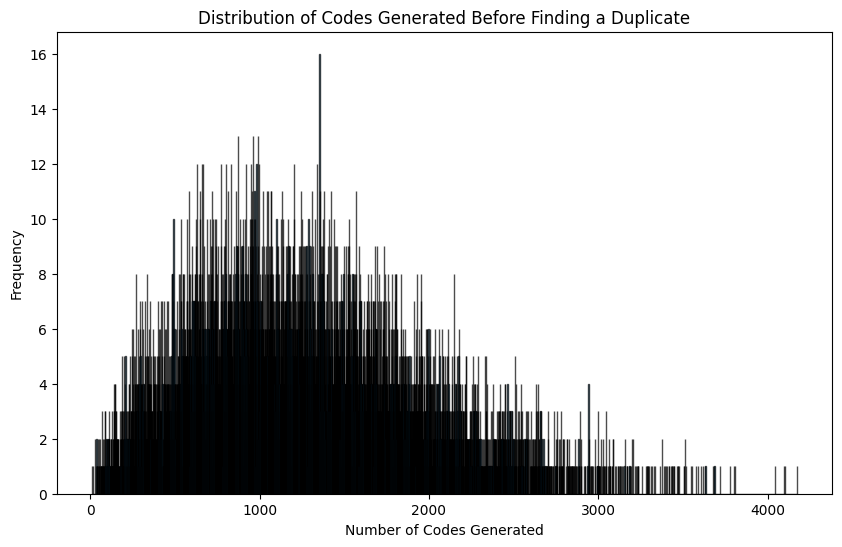

In [1]:
# Investigate the question of getting duplicate codes for authentication

import numpy as np
import matplotlib.pyplot as plt

# Code size
code_size = 6  # Number of digits in the code
# Total number of unique codes
total_codes = 10 ** code_size

# generate an initial code
def generate_code():
    return np.random.randint(0, total_codes)

num_sims = 10000  # Number of simulations to run
# Store the number of codes generated before finding a duplicate
codes_before_duplicate = []

for i in range(num_sims):

    initial_code = generate_code()
    stored_codes = [initial_code]
    number_of_codes = 1
    # print the initial code
    #print(f"Initial code: {initial_code}")

    while True:
        # Generate a new code
        new_code = generate_code()
        number_of_codes += 1
        # Print the new code
        #print(f"New code: {new_code}")
    
        # Check if the new code is the same as any of the previous codes
        if new_code in stored_codes:
            #print(f"Duplicate code found: {new_code}")
            break
        else:
            stored_codes.append(new_code)
        
    # Print the number of codes generated before finding a duplicate
    #print(f"Number of codes generated before finding a duplicate: {number_of_codes}")
    codes_before_duplicate.append(number_of_codes)
    
# Plot the results
print(f"Average number of codes generated before finding a duplicate: {np.mean(codes_before_duplicate)}")
upper_limit = max(codes_before_duplicate)
plt.figure(figsize=(10, 6))
plt.hist(codes_before_duplicate, bins=2*upper_limit, edgecolor='black', alpha=0.7)
plt.title('Distribution of Codes Generated Before Finding a Duplicate')
plt.xlabel('Number of Codes Generated')
plt.ylabel('Frequency')

plt.show()


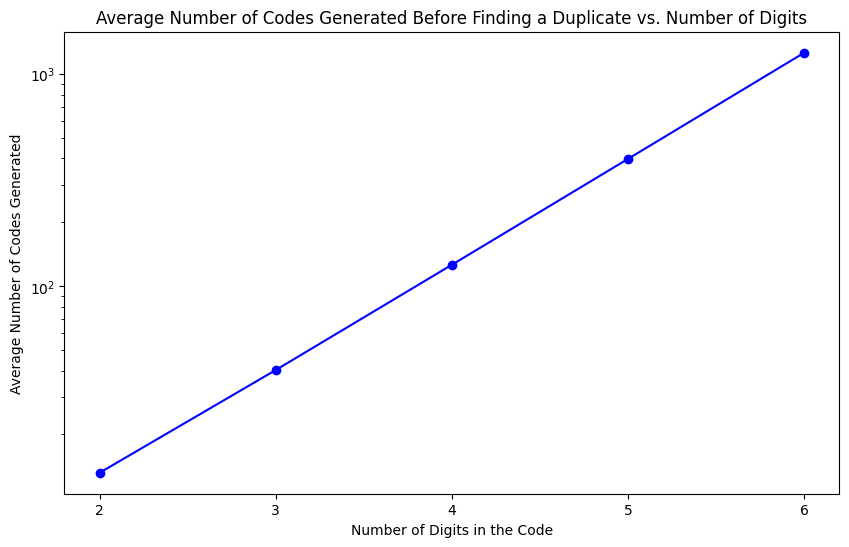

In [2]:
num_digits = [2,3,4,5,6]
average = [13.2,40.26,126.2,398.34,1260.5]

plt.figure(figsize=(10, 6))
plt.plot(num_digits, average, marker='o', linestyle='-', color='b')
plt.title('Average Number of Codes Generated Before Finding a Duplicate vs. Number of Digits')
plt.xlabel('Number of Digits in the Code')
plt.ylabel('Average Number of Codes Generated')
plt.xticks(num_digits)
plt.yscale('log')

plt.show()

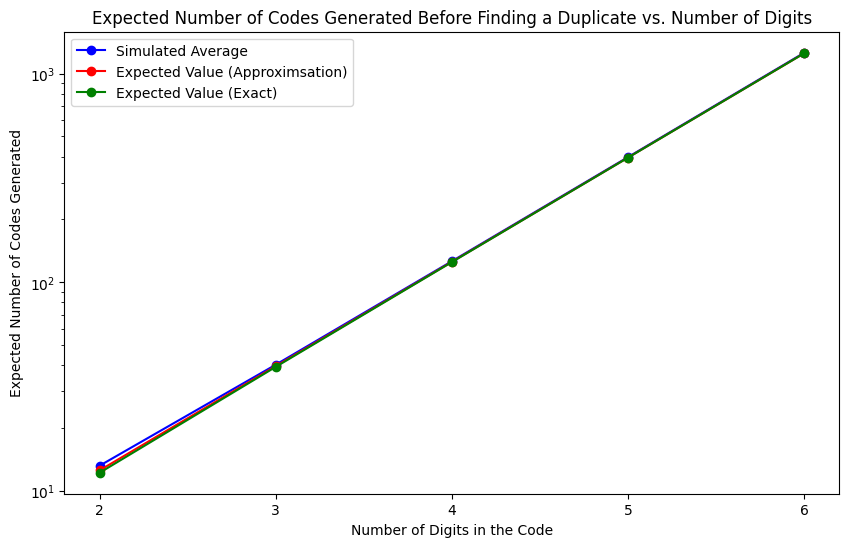

In [3]:
# Theory

# The expected number of codes generated before finding a duplicate can be approximated.
# The formula is:
# E(n) = sqrt(pi * N / 2)
# Where:
# E(n) is the expected number of codes generated before finding a duplicate,
# N is the total number of unique codes.

import math
def expected_codes_before_duplicate(code_size):
    total_codes = 10 ** code_size
    return math.sqrt(np.pi * total_codes /2)

# Calculate expected values for different code sizes
expected_values = [expected_codes_before_duplicate(size) for size in num_digits]

# Exact expected values for the given code sizes

# The expectation values for the given code sizes can be calculated as follows:
# E = sum_0^N N_M / N^m 
# Where N is the total number of unique codes and
# N_M = N(N-1)(N-2)...(N-m+1) is the number of ways to choose m codes from N codes without replacement.

def N_M_divided(N, m):
    if m == 1:
        return 1
    result = 1
    for i in range(m):
        result *= (N - i)
    return result/N**m

def exact_expected_codes_before_duplicate_exact(code_size):
    total_codes = 10 ** code_size
    expected_value = 0
    for m in range(1, total_codes + 1):
        expected_value += N_M_divided(total_codes, m)
        #print(f"m: {m}, N_M_divided: {N_M_divided(total_codes, m)}")
        if N_M_divided(total_codes, m) < 1e-4:
            break
    return expected_value
        
# Calculate exact expected values for different code sizes
exact_expected_values = [exact_expected_codes_before_duplicate_exact(size) for size in num_digits]

# Plot the expected values
plt.figure(figsize=(10, 6))
plt.plot(num_digits, average, marker='o', linestyle='-', color='b')
plt.plot(num_digits, expected_values, marker='o', linestyle='-', color='r')
plt.plot(num_digits, exact_expected_values, marker='o', linestyle='-', color='g')

plt.title('Expected Number of Codes Generated Before Finding a Duplicate vs. Number of Digits')
plt.xlabel('Number of Digits in the Code')
plt.ylabel('Expected Number of Codes Generated')
plt.xticks(num_digits)
plt.yscale('log')
plt.legend(['Simulated Average', 'Expected Value (Approximsation)', 'Expected Value (Exact)'])
plt.show()